### **👩‍🏫 👩🏿‍🏫 What You'll learn**

- Data visualization with scatter plots.
- Basic understanding of logistic regression.
- Applying a logistic regression model to binary classification.
- Interpreting the results of logistic regression.

---

### **🛠️ What you will create**

You will create a logistic regression model that uses examination scores to predict university admission.
dataset available [here](https://github.com/kaleko/CourseraML/blob/master/ex2/data/ex2data1.txt)

---

### **Your Task**

1. Data Exploration: Load and visualize the data.
	- Use `pandas` to load the dataset and examine the first few rows.
	- Create a scatter plot to visualize the data points for students who were admitted versus those who were not based on their exam scores.
2. Applying Logistic Regression with `scikit-learn`:
	- Implement logistic regression using the `LogisticRegression` function from `scikit-learn` to find the best parameters for your model.
	- Train the logistic regression model on your dataset.
3. Making Predictions:
	- Use the trained logistic regression model to make predictions on your dataset.
	- Calculate the accuracy of your model.
4. Model Evaluation:
	- Interpret the result of logistic regression and the accuracy of your model.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df = pd.read_csv('/content/drive/MyDrive/DI-Bootcamp/Week5/Day1/DailyChallenge/ex2data1.txt', header=None, names=['exam1', 'exam2', 'admitted'])

In [5]:
print(df.shape)
display(df.head())
print(df['admitted'].value_counts())

(100, 3)


,exam1,exam2,admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


admitted
1    60
0    40
Name: count, dtype: int64


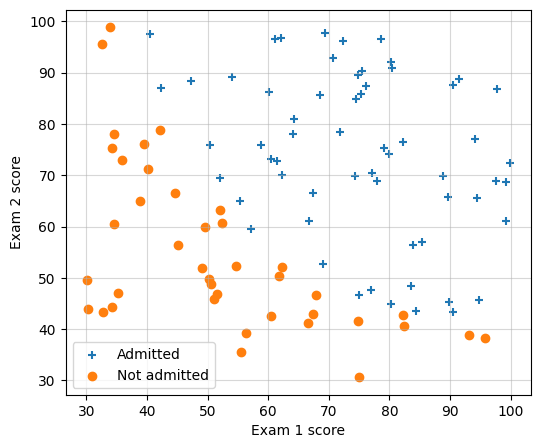

In [8]:
admitted = df[df['admitted'] == 1]
not_admitted = df[df['admitted'] == 0]

plt.figure(figsize=(6, 5))
plt.scatter(admitted['exam1'], admitted['exam2'], marker='+', label='Admitted')
plt.scatter(not_admitted['exam1'], not_admitted['exam2'], marker='o', label='Not admitted')
plt.xlabel('Exam 1 score')
plt.ylabel('Exam 2 score')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

In [11]:
X = df[['exam1', 'exam2']]
y = df['admitted']

model = LogisticRegression()
model.fit(X, y)

print(f'Coefficients: {model.coef_}')
print(f'Intercept: {model.intercept_}')

Coefficients: [[0.20535491 0.2005838 ]]
Intercept: [-25.05219314]


In [13]:
y_pred = model.predict(X)
accuracy = accuracy_score(y, y_pred)

print(f'Accuracy: {round(accuracy, 4)}')

Accuracy: 0.89


Both coefficients (0.205, 0.200) are positive, meaning higher scores on either exam push the direction toward `admitted`, and they're almost identical in size, so the model treats the two exams as roughly equally important.
The intercept (-25.05) means that with 0 on both exams, the model is extremely confident that the student is not admitted. The exam scores have to climb a long way before their positive coefficients can offset that intercept, and push the prediction past the 50% admission threshold.
For example, if a student scored 60 on exam1, they'd need to score roughly `(25.05 - 0.205 * 60) / 0.200 = ~63` on exam2 to cross into 'likely admitted' terrirory, which matches the diagonal separation we see on the scatter plot.

The accuracy (89%) means that in our training data, the model correctly guesses whether the student is admitted or not based on the exam scores 89% of the times.